
1. DATA CLEANING


In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/mail_data.csv')

In [3]:
df.sample(5)

,Category,Message
540,ham,"I am in tirupur da, once you started from offi..."
4917,ham,"Just dropped em off, omw back now"
1809,ham,Aiyo a bit pai seh ü noe... Scared he dun rem ...
3386,ham,Ok can...
2791,spam,U’ve Bin Awarded £50 to Play 4 Instant Cash. C...


In [4]:
df.shape

(5572, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])

In [7]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Check nulls

In [8]:
df.isnull().sum()

,0
Category,0
Message,0


# Remove duplicates

In [9]:
df.duplicated().sum()


np.int64(415)

In [10]:
df = df.drop_duplicates(keep='first')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(5157, 2)

2. EDA

In [13]:
df['Category'].value_counts()

,count
Category,
0,4516
1,641


In [14]:
import matplotlib.pyplot as plt

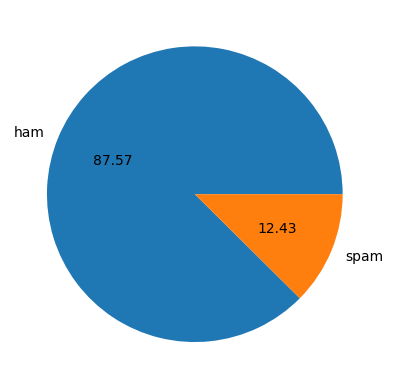

In [15]:
plt.pie(df['Category'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [16]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Feature engineering

In [17]:
df['num_characters'] = df['Message'].apply(len)
df['num_words']      = df['Message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences']  = df['Message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [18]:
df.head()
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560403,1.969750
std,58.382922,13.405970,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


# Stats split by class

In [19]:
print("── HAM stats ──")
print(df[df['Category'] == 0][['num_characters', 'num_words', 'num_sentences']].describe())

── HAM stats ──
       num_characters    num_words  num_sentences
count     4516.000000  4516.000000    4516.000000
mean        70.869353    17.267715       1.827724
std         56.708301    13.588065       1.394338
min          2.000000     1.000000       1.000000
25%         34.000000     8.000000       1.000000
50%         53.000000    13.000000       1.000000
75%         91.000000    22.000000       2.000000
max        910.000000   220.000000      38.000000


In [20]:
print("\n── SPAM stats ──")
print(df[df['Category'] == 1][['num_characters', 'num_words', 'num_sentences']].describe())


── SPAM stats ──
       num_characters   num_words  num_sentences
count      641.000000  641.000000     641.000000
mean       137.118565   27.667707       2.970359
std         30.399707    7.103501       1.485575
min          7.000000    2.000000       1.000000
25%        130.000000   25.000000       2.000000
50%        148.000000   29.000000       3.000000
75%        157.000000   32.000000       4.000000
max        223.000000   46.000000       9.000000


In [21]:
import seaborn as sns

# Character distribution

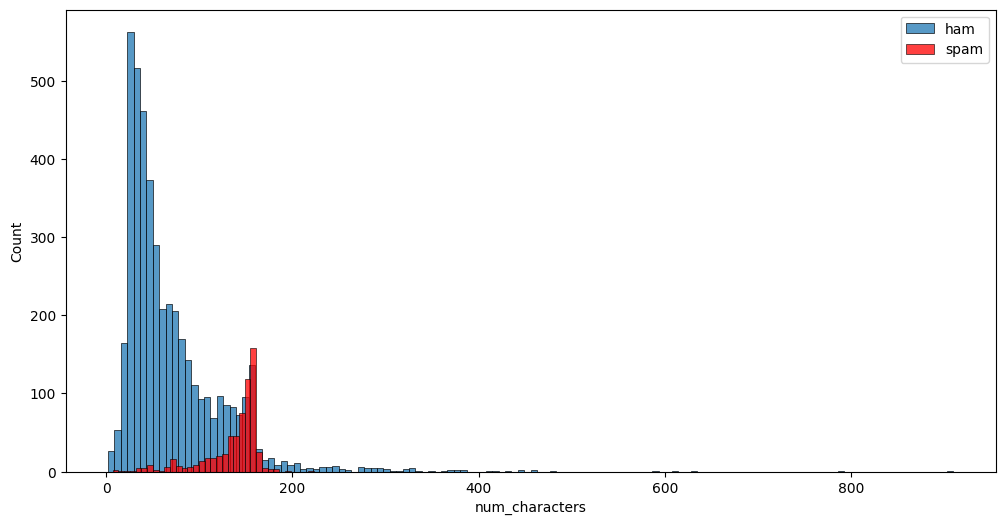

In [22]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Category'] == 0]['num_characters'], label='ham')
sns.histplot(df[df['Category'] == 1]['num_characters'], color='red', label='spam')
plt.legend()
plt.show()

# Word distribution

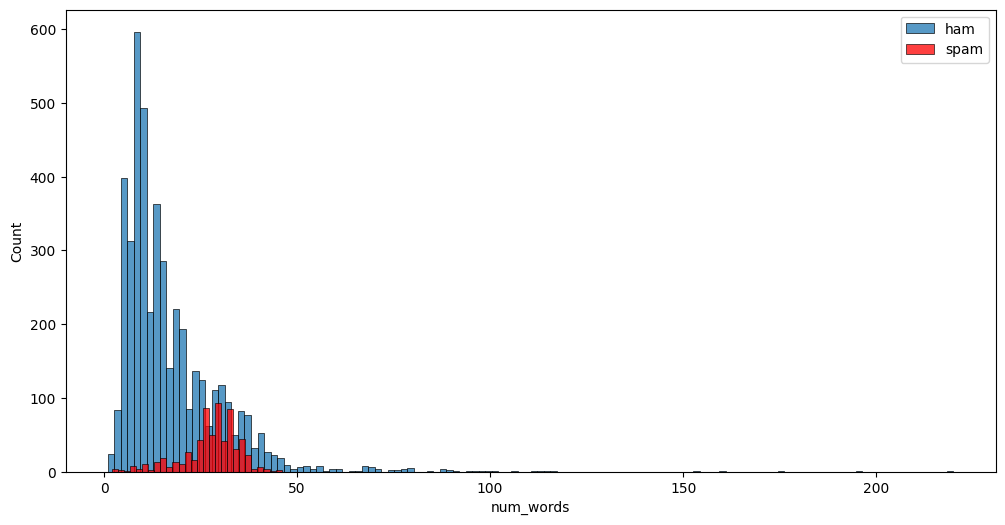

In [23]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Category'] == 0]['num_words'], label='ham')
sns.histplot(df[df['Category'] == 1]['num_words'], color='red', label='spam')
plt.legend()
plt.show()

Pairplot

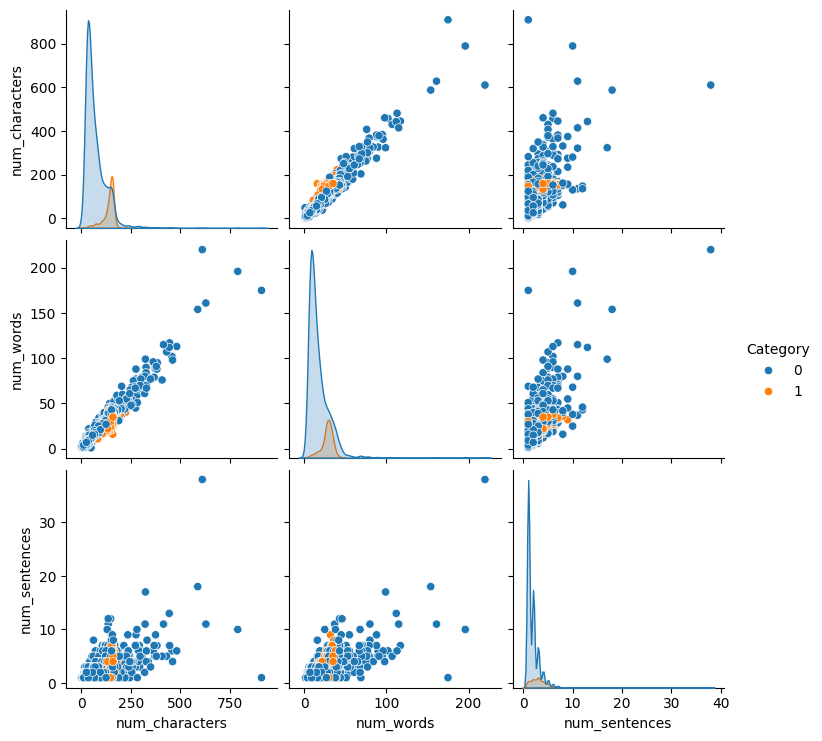

In [24]:
sns.pairplot(df, hue='Category')
plt.show()

# Correlation heatmap

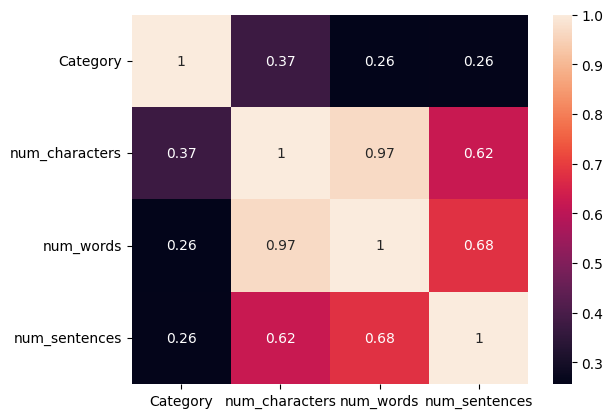

In [25]:
numerical_features   = df.select_dtypes(include=np.number).columns
correlation_matrix   = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()


3. TEXT PREPROCESSING
   1. Lowercase
   2. Tokenize
   3. Remove special chars
   4. Remove stopwords & punctuation  
   5. Stemming

In [26]:
from nltk.corpus import stopwords
import string
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [27]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    # Remove non-alphanumeric tokens
    y = [i for i in text if i.isalnum()]

    # Remove stopwords and punctuation
    y = [i for i in y if i not in stopwords.words('english')
                      and i not in string.punctuation]

    # Stemming
    y = [ps.stem(i) for i in y]

    return " ".join(y)


In [28]:
print(transform_text('Hello Working are you?'))

hello work


In [29]:
df['transformed_text'] = df['Message'].apply(transform_text)
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


Word Clouds

In [30]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

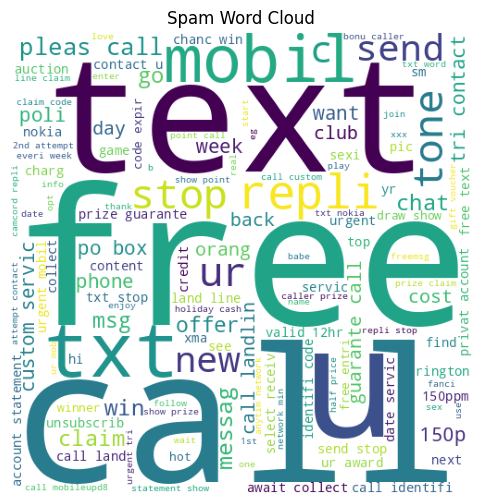

In [31]:
spam_wc = wc.generate(df[df['Category'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()


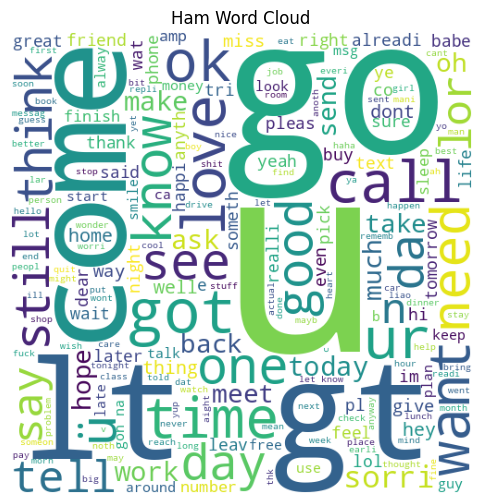

In [32]:
ham_wc = wc.generate(df[df['Category'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(ham_wc)
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()

Top 30 words in spam & ham

Spam corpus size: 9781


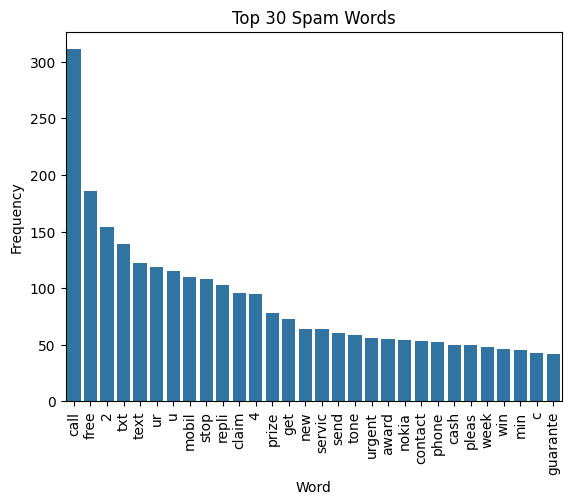

In [33]:
from collections import Counter

spam_corpus = [word for msg in df[df['Category'] == 1]['transformed_text'].tolist()
               for word in msg.split()]
print(f"Spam corpus size: {len(spam_corpus)}")   # 9781

spam_corpus_df = pd.DataFrame(Counter(spam_corpus).most_common(30),
                               columns=['Word', 'Frequency'])
sns.barplot(x='Word', y='Frequency', data=spam_corpus_df)
plt.xticks(rotation='vertical')
plt.title("Top 30 Spam Words")
plt.show()

Ham corpus size: 35940


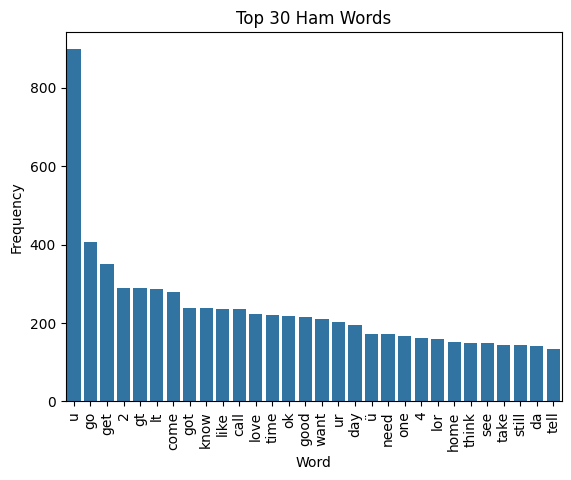

In [34]:
ham_corpus = [word for msg in df[df['Category'] == 0]['transformed_text'].tolist()
              for word in msg.split()]
print(f"Ham corpus size: {len(ham_corpus)}")     # 35940

ham_corpus_df = pd.DataFrame(Counter(ham_corpus).most_common(30),
                              columns=['Word', 'Frequency'])
sns.barplot(x='Word', y='Frequency', data=ham_corpus_df)
plt.xticks(rotation='vertical')
plt.title("Top 30 Ham Words")
plt.show()

MODEL BUILDING — Traditional ML (TF-IDF)

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [36]:
cv    = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [37]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['Category'].values

In [38]:
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (5157, 3000)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# Naive Bayes variants

In [40]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [41]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

Gaussian NB

In [42]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("\nGaussianNB:")
print("Accuracy :", accuracy_score(y_test, y_pred1))
print("Confusion:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))


GaussianNB:
Accuracy : 0.8682170542635659
Confusion:
 [[786 119]
 [ 17 110]]
Precision: 0.48034934497816595


Multinomial NB

In [43]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("\nMultinomialNB:")
print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Confusion:\n", confusion_matrix(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))


MultinomialNB:
Accuracy : 0.9718992248062015
Confusion:
 [[905   0]
 [ 29  98]]
Precision: 1.0


Bernoulli NB

In [44]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("\nBernoulliNB:")
print("Accuracy :", accuracy_score(y_test, y_pred3))
print("Confusion:\n", confusion_matrix(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))


BernoulliNB:
Accuracy : 0.9825581395348837
Confusion:
 [[903   2]
 [ 16 111]]
Precision: 0.9823008849557522


Multiple classifiers comparison

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier,
                                        AdaBoostClassifier,
                                        BaggingClassifier,
                                        ExtraTreesClassifier,
                                        GradientBoostingClassifier)
from xgboost import XGBClassifier

In [46]:
svc  = SVC(kernel='sigmoid', gamma=1.0, probability=True)
knc  = KNeighborsClassifier()
mnb  = MultinomialNB()
dtc  = DecisionTreeClassifier(max_depth=5)
lrc  = LogisticRegression(solver='liblinear', penalty='l1')
rfc  = RandomForestClassifier(n_estimators=50, random_state=2)
abc  = AdaBoostClassifier(n_estimators=50, random_state=2)
bc   = BaggingClassifier(n_estimators=50, random_state=2)
etc  = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb  = XGBClassifier(n_estimators=50, random_state=2)

In [47]:
clfs = {
    'SVC': svc, 'KN': knc,  'NB': mnb,  'DT': dtc,
    'LR':  lrc, 'RF': rfc, 'AdaBoost': abc,
    'BgC': bc,  'ETC': etc, 'GBDT': gbdt, 'xgb': xgb
}

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def train_classifier(clf, X_train, y_train, X_test, y_test):

    # train model
    clf.fit(X_train, y_train)

    # prediction
    y_pred = clf.predict(X_test)

    # metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    return accuracy, precision, recall, f1, weighted_f1

In [49]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
weighted_f1_scores = []
model_names = []

In [50]:
for name, clf in clfs.items():

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    # metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # store metrics
    accuracy_scores.append(acc)

    precision_scores.append(prec)

    recall_scores.append(recall)

    f1_scores.append(f1)

    weighted_f1_scores.append(weighted_f1)

    # =====================================
    # TESTING ACCURACY
    # =====================================

    print("\n===================================")

    print(f"{name} Testing Accuracy : {acc:.4f}")

    print("===================================\n")

    # =====================================
    # CLASSIFICATION REPORT
    # =====================================

    print(f"Classification Report for {name}\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['ham', 'spam']
        )
    )


SVC Testing Accuracy : 0.9777

Classification Report for SVC

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       905
        spam       0.99      0.83      0.90       127

    accuracy                           0.98      1032
   macro avg       0.98      0.91      0.94      1032
weighted avg       0.98      0.98      0.98      1032


KN Testing Accuracy : 0.9128

Classification Report for KN

              precision    recall  f1-score   support

         ham       0.91      1.00      0.95       905
        spam       1.00      0.29      0.45       127

    accuracy                           0.91      1032
   macro avg       0.95      0.65      0.70      1032
weighted avg       0.92      0.91      0.89      1032


NB Testing Accuracy : 0.9719

Classification Report for NB

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       905
        spam       1.00      0.77      0.87       12

In [51]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores,
    'Weighted F1': weighted_f1_scores
})

print("\n",
      performance_df.sort_values(
          'Weighted F1',
          ascending=False
      ).to_string(index=False))


 Algorithm  Accuracy  Precision   Recall  F1 Score  Weighted F1
      SVC  0.977713   0.990566 0.826772  0.901288     0.976837
      xgb  0.973837   0.980769 0.803150  0.883117     0.972699
      ETC  0.971899   0.990000 0.779528  0.872247     0.970435
       NB  0.971899   1.000000 0.771654  0.871111     0.970310
       RF  0.970930   0.989899 0.771654  0.867257     0.969351
      BgC  0.964147   0.894737 0.803150  0.846473     0.963308
       LR  0.958333   0.937500 0.708661  0.807175     0.955788
     GBDT  0.952519   0.975610 0.629921  0.765550     0.947984
       DT  0.936047   0.814433 0.622047  0.705357     0.932285
 AdaBoost  0.928295   0.844156 0.511811  0.637255     0.920471
       KN  0.912791   1.000000 0.291339  0.451220     0.890927


In [52]:
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")

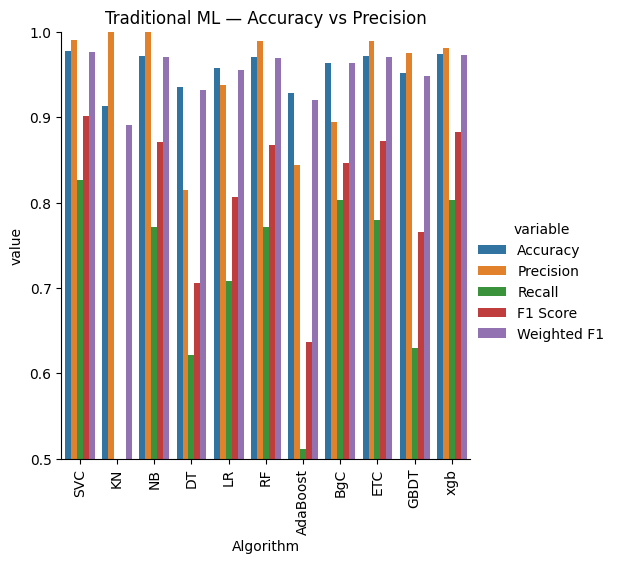

In [53]:
sns.catplot(x='Algorithm', y='value', hue='variable',
            data=performance_df1, kind='bar', height=5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.title("Traditional ML — Accuracy vs Precision")
plt.show()

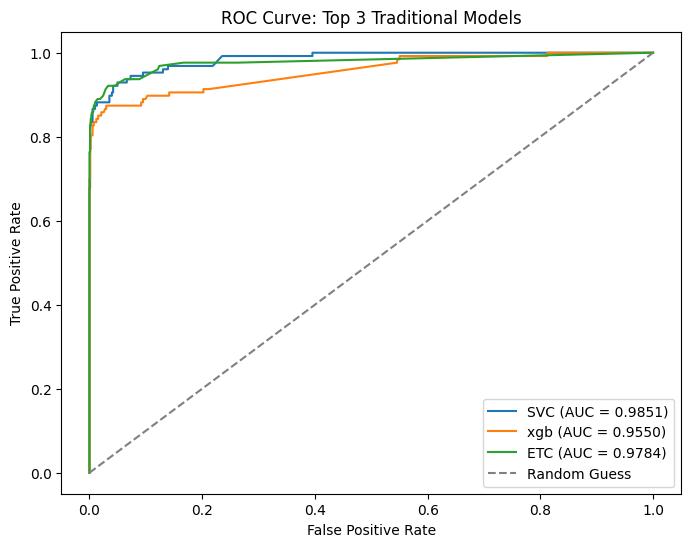

In [54]:
# =========================================================
# ROC / AUC FOR TOP 3 TRADITIONAL MODELS
# =========================================================
from sklearn.metrics import roc_curve, auc

# Select the top 3 models
top_models = ['SVC', 'xgb', 'ETC']

plt.figure(figsize=(8, 6))

for name in top_models:
    clf = clfs[name]
    # Predict probabilities
    y_prob = clf.predict_proba(X_test)[:, 1]

    # Calculate ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Top 3 Traditional Models")
plt.legend()
plt.show()

BERT FINE-TUNED CLASSIFIER
    Uses original messages (not stemmed) — BERT handles NLP

In [55]:
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from sklearn.metrics import classification_report

Split on original messages

In [56]:
X_bert = df['Message'].values
y_bert = df['Category'].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=2
)

Tokenizer

In [57]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN   = 128

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Custom Dataset

In [58]:
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE    = 16
train_dataset = SpamDataset(X_train_b, y_train_b, tokenizer, MAX_LEN)
test_dataset  = SpamDataset(X_test_b,  y_test_b,  tokenizer, MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

Model setup

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
).to(device)

EPOCHS      = 3
optimizer   = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [60]:
# =====================================================
# MODEL SETUP
# CUSTOM BERT MODEL WITH DENSE LAYER
# =====================================================

from transformers import BertModel
import torch
import torch.nn as nn


# =====================================================
# BERT CLASSIFIER
# =====================================================

class BERTClassifier(nn.Module):

    def __init__(self):

        super(BERTClassifier, self).__init__()

        # pretrained BERT model
        self.bert = BertModel.from_pretrained(
            'bert-base-uncased'
        )

        # dropout layer
        self.dropout = nn.Dropout(0.3)

        # dense layer
        # 768 = BERT hidden size
        # 2 = ham / spam classes
        self.linear = nn.Linear(
            768,
            2
        )

    def forward(self, input_ids, attention_mask):

        # BERT output
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # pooled output
        pooled_output = outputs.pooler_output

        # dropout
        dropout_output = self.dropout(
            pooled_output
        )

        # dense layer
        logits = self.linear(
            dropout_output
        )

        return logits


# =====================================================
# INITIALIZE MODEL
# =====================================================

model = BERTClassifier()

# move model to GPU / CPU
model.to(device)


# =====================================================
# OUTPUTS
# =====================================================

print("\n====================================")

print("BERT Model with Dense Layer Loaded")

print("====================================\n")

# full architecture
print(model)

# dense layer details
print("\n====================================")

print("Dense Layer Details")

print("====================================\n")

print(model.linear)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BERT Model with Dense Layer Loaded

BERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerN

 Training function

In [61]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

Evaluation function

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT Confusion Matrix

[[  0 905]
 [  0 127]]


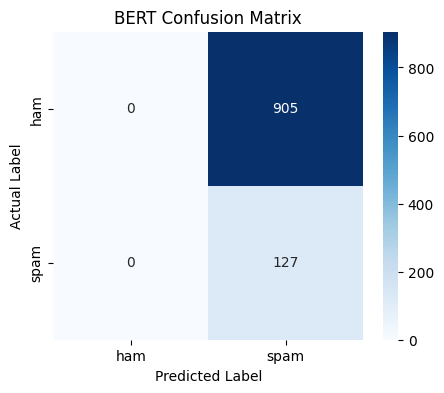


BERT Classification Report

              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       905
        spam       0.12      1.00      0.22       127

    accuracy                           0.12      1032
   macro avg       0.06      0.50      0.11      1032
weighted avg       0.02      0.12      0.03      1032

Testing Accuracy : 0.12306201550387597
Precision        : 0.12306201550387597
Recall           : 1.0
F1 Score         : 0.2191544434857636
Weighted F1      : 0.02696958752198835

UPDATED PERFORMANCE TABLE

Algorithm  Accuracy  Precision   Recall  F1 Score  Weighted F1
      SVC  0.977713   0.990566 0.826772  0.901288     0.976837
      xgb  0.973837   0.980769 0.803150  0.883117     0.972699
      ETC  0.971899   0.990000 0.779528  0.872247     0.970435
       NB  0.971899   1.000000 0.771654  0.871111     0.970310
       RF  0.970930   0.989899 0.771654  0.867257     0.969351
      BgC  0.964147   0.894737 0.803150  0.846473     0.9633

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


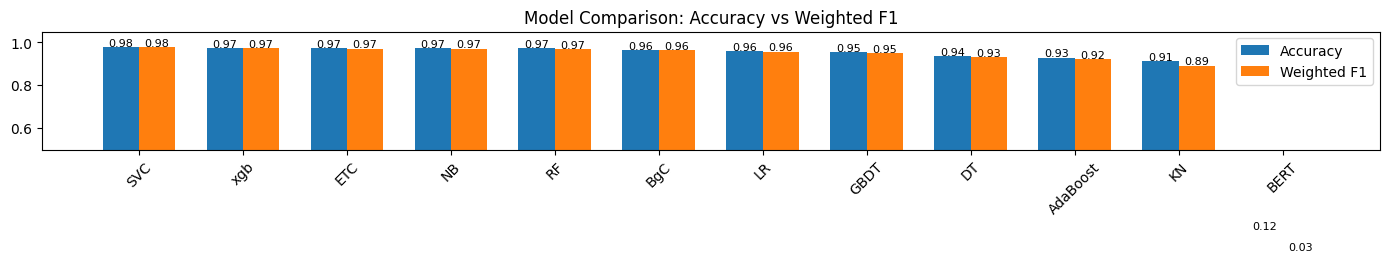

In [62]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from transformers import BertForSequenceClassification


# =========================================================
# LOAD BERT MODEL
# =========================================================

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# move model to GPU/CPU
bert_model.to(device)


# =========================================================
# BERT EVALUATION FUNCTION
# =========================================================

def evaluate_bert(model, loader, device):

    # set model to evaluation mode
    model.eval()

    all_preds = []
    all_labels = []

    # disable gradient calculation
    with torch.no_grad():

        for batch in loader:

            # move data to device
            input_ids = batch['input_ids'].to(device)

            attention_mask = batch['attention_mask'].to(device)

            labels = batch['label'].to(device)

            # model prediction
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # predicted class
            preds = torch.argmax(
                outputs.logits,
                dim=1
            )

            # store predictions
            all_preds.extend(
                preds.cpu().numpy()
            )

            # store actual labels
            all_labels.extend(
                labels.cpu().numpy()
            )

    # =========================================================
    # TESTING ACCURACY
    # =========================================================

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    # =========================================================
    # PRECISION
    # =========================================================

    prec = precision_score(
        all_labels,
        all_preds
    )

    # =========================================================
    # RECALL
    # =========================================================

    recall = recall_score(
        all_labels,
        all_preds
    )

    # =========================================================
    # F1 SCORE
    # =========================================================

    f1 = f1_score(
        all_labels,
        all_preds
    )

    # =========================================================
    # WEIGHTED F1 SCORE
    # =========================================================

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    # =========================================================
    # CONFUSION MATRIX
    # =========================================================

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    print("\n========================================")

    print("BERT Confusion Matrix")

    print("========================================\n")

    print(cm)

    # =========================================================
    # CONFUSION MATRIX HEATMAP
    # =========================================================

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['ham', 'spam'],
        yticklabels=['ham', 'spam']
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("Actual Label")

    plt.title("BERT Confusion Matrix")

    plt.show()

    # =========================================================
    # CLASSIFICATION REPORT
    # =========================================================

    print("\n========================================")

    print("BERT Classification Report")

    print("========================================\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=['ham', 'spam']
        )
    )

    # =========================================================
    # PRINT ALL METRICS
    # =========================================================

    print("Testing Accuracy :", acc)

    print("Precision        :", prec)

    print("Recall           :", recall)

    print("F1 Score         :", f1)

    print("Weighted F1      :", weighted_f1)

    # =========================================================
    # RETURN VALUES
    # =========================================================

    return (
        acc,
        prec,
        recall,
        f1,
        weighted_f1,
        all_preds,
        all_labels
    )


# =========================================================
# RUN BERT EVALUATION
# =========================================================

bert_acc, bert_prec, bert_recall, bert_f1, bert_weighted_f1, bert_preds, bert_true = evaluate_bert(
    bert_model,
    test_loader,
    device
)


# =========================================================
# ADD BERT TO PERFORMANCE TABLE
# =========================================================

performance_df.loc[len(performance_df)] = [
    'BERT',
    bert_acc,
    bert_prec,
    bert_recall,
    bert_f1,
    bert_weighted_f1
]


# =========================================================
# SHOW UPDATED PERFORMANCE TABLE
# =========================================================

print("\n========================================")

print("UPDATED PERFORMANCE TABLE")

print("========================================\n")

print(
    performance_df.sort_values(
        'Weighted F1',
        ascending=False
    ).to_string(index=False)
)


# =========================================================
# VISUALIZE PERFORMANCE COMPARISON
# =========================================================

plt.figure(figsize=(14,5))

performance_df_sorted = performance_df.sort_values(
    'Weighted F1',
    ascending=False
)

x = range(len(performance_df_sorted))

width = 0.35

bars1 = plt.bar(
    [i - width/2 for i in x],
    performance_df_sorted['Accuracy'],
    width,
    label='Accuracy'
)

bars2 = plt.bar(
    [i + width/2 for i in x],
    performance_df_sorted['Weighted F1'],
    width,
    label='Weighted F1'
)

# values on top of bars
for bar in bars1:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=8
    )

for bar in bars2:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=8
    )

plt.xticks(
    x,
    performance_df_sorted['Algorithm'],
    rotation=45
)

plt.ylim(0.5, 1.05)

plt.legend()

plt.title(
    "Model Comparison: Accuracy vs Weighted F1"
)

plt.tight_layout()

plt.show()

Run training


── BERT Fine-tuning ──

BERT Confusion Matrix

[[  0 905]
 [  0 127]]


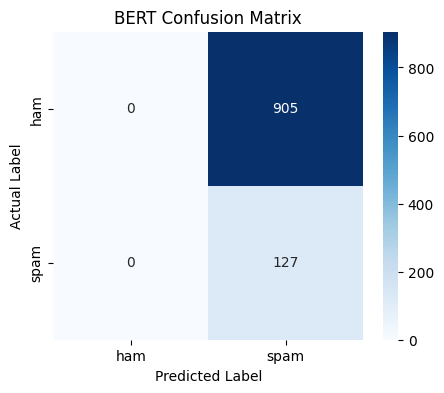


BERT Classification Report

              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       905
        spam       0.12      1.00      0.22       127

    accuracy                           0.12      1032
   macro avg       0.06      0.50      0.11      1032
weighted avg       0.02      0.12      0.03      1032

Testing Accuracy : 0.12306201550387597
Precision        : 0.12306201550387597
Recall           : 1.0
F1 Score         : 0.2191544434857636
Weighted F1      : 0.02696958752198835
Epoch 1/3  Loss: 0.9131  Accuracy: 0.1231  Precision: 0.1231


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



BERT Confusion Matrix

[[  0 905]
 [  0 127]]


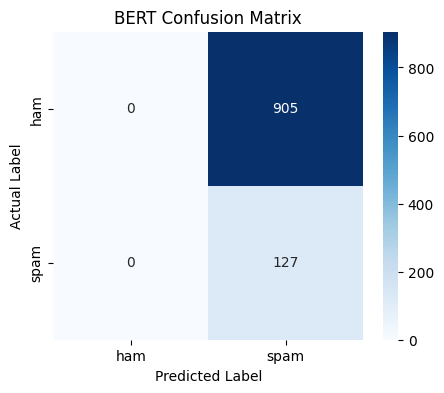


BERT Classification Report

              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       905
        spam       0.12      1.00      0.22       127

    accuracy                           0.12      1032
   macro avg       0.06      0.50      0.11      1032
weighted avg       0.02      0.12      0.03      1032

Testing Accuracy : 0.12306201550387597
Precision        : 0.12306201550387597
Recall           : 1.0
F1 Score         : 0.2191544434857636
Weighted F1      : 0.02696958752198835
Epoch 2/3  Loss: 0.9100  Accuracy: 0.1231  Precision: 0.1231


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



BERT Confusion Matrix

[[  0 905]
 [  0 127]]


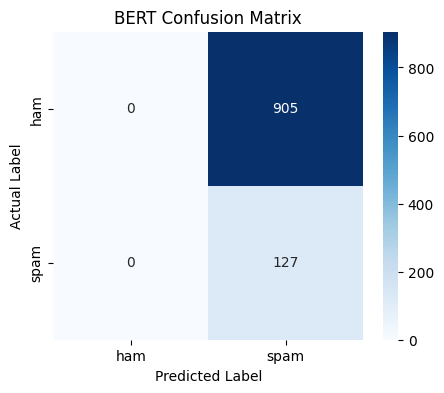


BERT Classification Report

              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       905
        spam       0.12      1.00      0.22       127

    accuracy                           0.12      1032
   macro avg       0.06      0.50      0.11      1032
weighted avg       0.02      0.12      0.03      1032

Testing Accuracy : 0.12306201550387597
Precision        : 0.12306201550387597
Recall           : 1.0
F1 Score         : 0.2191544434857636
Weighted F1      : 0.02696958752198835
Epoch 3/3  Loss: 0.9110  Accuracy: 0.1231  Precision: 0.1231


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



BERT Confusion Matrix

[[  0 905]
 [  0 127]]


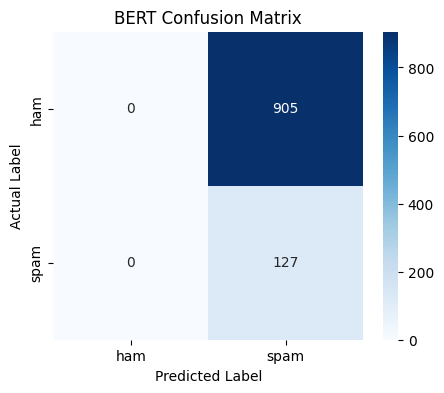


BERT Classification Report

              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       905
        spam       0.12      1.00      0.22       127

    accuracy                           0.12      1032
   macro avg       0.06      0.50      0.11      1032
weighted avg       0.02      0.12      0.03      1032

Testing Accuracy : 0.12306201550387597
Precision        : 0.12306201550387597
Recall           : 1.0
F1 Score         : 0.2191544434857636
Weighted F1      : 0.02696958752198835

BERT — Accuracy: 0.1231  Precision: 0.1231

Classification Report:
               precision    recall  f1-score   support

         ham       0.00      0.00      0.00       905
        spam       0.12      1.00      0.22       127

    accuracy                           0.12      1032
   macro avg       0.06      0.50      0.11      1032
weighted avg       0.02      0.12      0.03      1032



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [63]:
print("\n── BERT Fine-tuning ──")
for epoch in range(EPOCHS):
    avg_loss          = train_epoch(bert_model, train_loader, optimizer, scheduler, device)
    acc, prec, recall, f1, w_f1, preds, labels = evaluate_bert(bert_model, test_loader, device)
    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {avg_loss:.4f}  "
          f"Accuracy: {acc:.4f}  Precision: {prec:.4f}")

bert_acc, bert_prec, bert_recall, bert_f1, bert_weighted_f1, bert_preds, bert_true = evaluate_bert(bert_model, test_loader, device)
print(f"\nBERT — Accuracy: {bert_acc:.4f}  Precision: {bert_prec:.4f}")
print("\nClassification Report:\n",
      classification_report(bert_true, bert_preds, target_names=['ham', 'spam']))

Add BERT to performance table

In [64]:
bert_row       = pd.DataFrame([{'Algorithm': 'BERT',
                                 'Accuracy':  bert_acc,
                                 'Precision': bert_prec}])
performance_df = pd.concat([performance_df, bert_row], ignore_index=True)

Visualise updated comparison

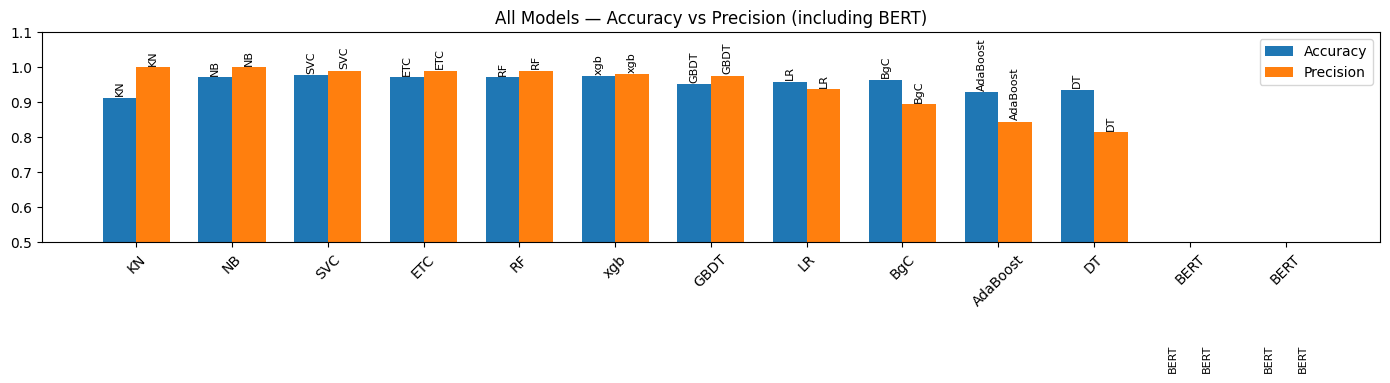

In [65]:
plt.figure(figsize=(14, 5))

performance_df_sorted = performance_df.sort_values(
    'Precision',
    ascending=False
)

x = range(len(performance_df_sorted))

width = 0.35

# bars
bars1 = plt.bar(
    [i - width/2 for i in x],
    performance_df_sorted['Accuracy'],
    width,
    label='Accuracy'
)

bars2 = plt.bar(
    [i + width/2 for i in x],
    performance_df_sorted['Precision'],
    width,
    label='Precision'
)

# model names on top
for i, model in enumerate(performance_df_sorted['Algorithm']):

    plt.text(
        i - width/2,
        performance_df_sorted['Accuracy'].iloc[i] + 0.01,
        model,
        ha='center',
        fontsize=8,
        rotation=90
    )

    plt.text(
        i + width/2,
        performance_df_sorted['Precision'].iloc[i] + 0.01,
        model,
        ha='center',
        fontsize=8,
        rotation=90
    )

# x-axis labels
plt.xticks(
    x,
    performance_df_sorted['Algorithm'],
    rotation=45
)

plt.ylim(0.5, 1.10)

plt.legend()

plt.title(
    "All Models — Accuracy vs Precision (including BERT)"
)

plt.tight_layout()

plt.show()

In [66]:
print(
    performance_df[
        ['Algorithm',
         'Accuracy',
         'Precision',
         'Recall',
         'F1 Score',
         'Weighted F1']
    ]
    .sort_values(
        'Weighted F1',
        ascending=False
    )
    .to_string(index=False)
)

Algorithm  Accuracy  Precision   Recall  F1 Score  Weighted F1
      SVC  0.977713   0.990566 0.826772  0.901288     0.976837
      xgb  0.973837   0.980769 0.803150  0.883117     0.972699
      ETC  0.971899   0.990000 0.779528  0.872247     0.970435
       NB  0.971899   1.000000 0.771654  0.871111     0.970310
       RF  0.970930   0.989899 0.771654  0.867257     0.969351
      BgC  0.964147   0.894737 0.803150  0.846473     0.963308
       LR  0.958333   0.937500 0.708661  0.807175     0.955788
     GBDT  0.952519   0.975610 0.629921  0.765550     0.947984
       DT  0.936047   0.814433 0.622047  0.705357     0.932285
 AdaBoost  0.928295   0.844156 0.511811  0.637255     0.920471
       KN  0.912791   1.000000 0.291339  0.451220     0.890927
     BERT  0.123062   0.123062 1.000000  0.219154     0.026970
     BERT  0.123062   0.123062      NaN       NaN          NaN


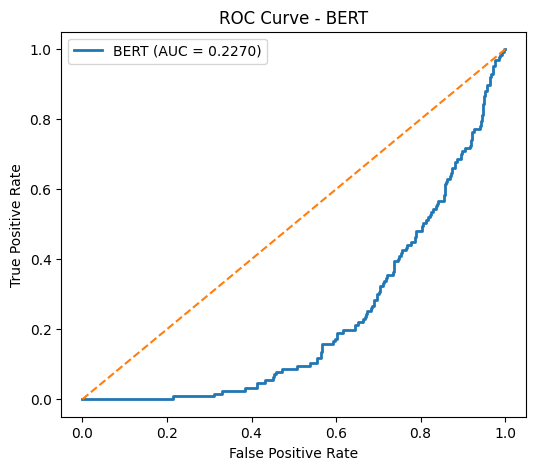

In [67]:
# =========================================================
# ROC / AUC FOR BERT
# =========================================================
import torch.nn.functional as F

def get_bert_probabilities(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # Apply Softmax to get probabilities
            probs = F.softmax(outputs.logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_probs

# Get BERT probs
bert_labels, bert_probs = get_bert_probabilities(bert_model, test_loader, device)

# Calculate BERT ROC/AUC
fpr_bert, tpr_bert, _ = roc_curve(bert_labels, bert_probs)
auc_bert = auc(fpr_bert, tpr_bert)

# Plot BERT Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_bert, tpr_bert, label=f'BERT (AUC = {auc_bert:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BERT")
plt.legend()
plt.show()

5. EVALUATION  (already done per-model above)

5B. SHAP EXPLAINABILITY
    Part A — Traditional ML (MultinomialNB + TF-IDF)
    Part B — BERT (token-level)

In [68]:
import shap
import warnings
warnings.filterwarnings('ignore')

 PART A: SHAP for MultinomialNB  (TF-IDF features)

In [69]:
print("\n── SHAP: MultinomialNB (TF-IDF) ──")

# Re-fit a clean MNB (already fitted above as mnb, but re-fit to be explicit)
from sklearn.naive_bayes import MultinomialNB
mnb_shap = MultinomialNB()
mnb_shap.fit(X_train, y_train)


── SHAP: MultinomialNB (TF-IDF) ──


MultinomialNB()

In [70]:
# 100-sample background keeps KernelExplainer fast
background      = shap.sample(X_train, 100, random_state=42)
explainer_mnb   = shap.KernelExplainer(
    model=mnb_shap.predict_proba,
    data=background
)

In [71]:
# Explain first 50 test samples (full test set is slow)
X_test_sample    = X_test[:50]
shap_values_mnb  = explainer_mnb.shap_values(X_test_sample, nsamples=100)
feature_names    = tfidf.get_feature_names_out()

  0%|          | 0/50 [00:00<?, ?it/s]

Plot A1: Global bar — top features driving spam

<Figure size 1000x600 with 0 Axes>

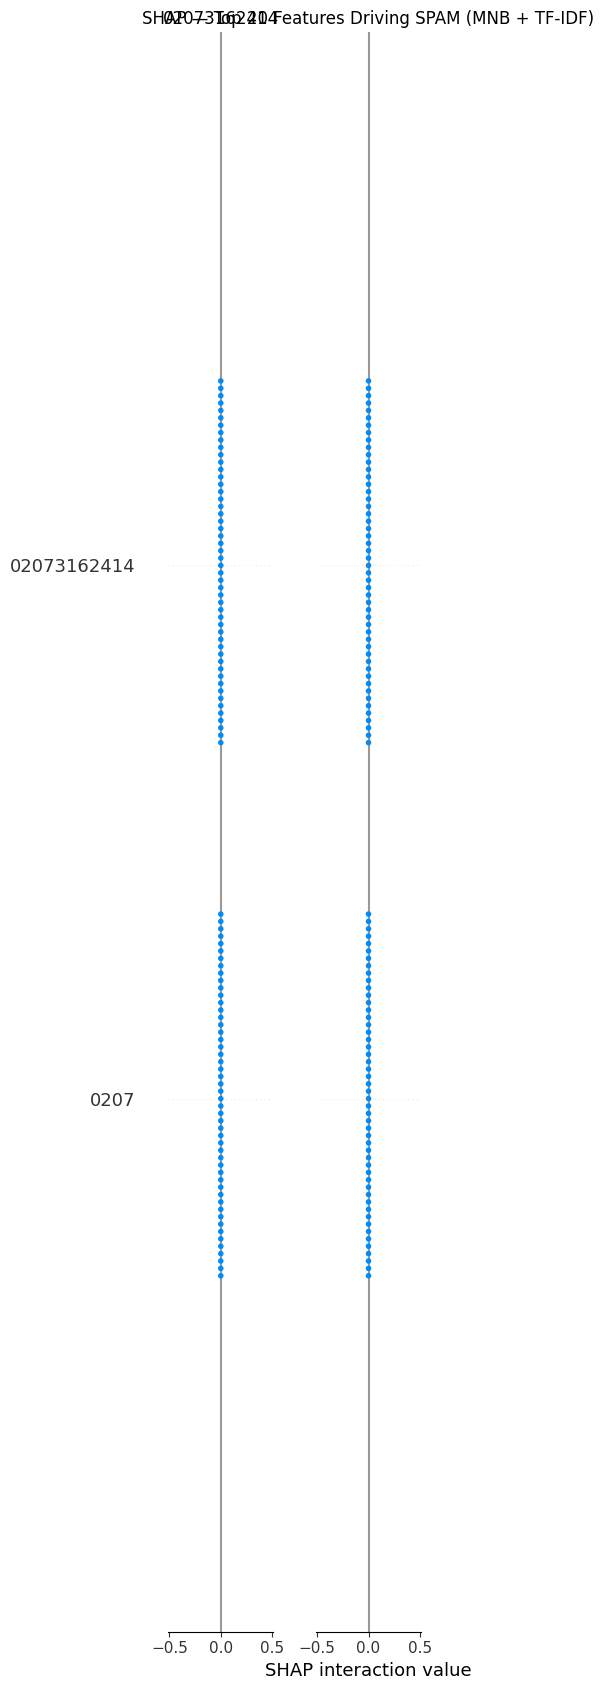

In [72]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_mnb,
    X_test_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)

plt.title("SHAP — Top 20 Features Driving SPAM (MNB + TF-IDF)")

plt.tight_layout()

plt.savefig('shap_mnb_bar.png', dpi=150)

plt.show()

Plot A2: Beeswarm — shows magnitude & direction

<Figure size 1000x600 with 0 Axes>

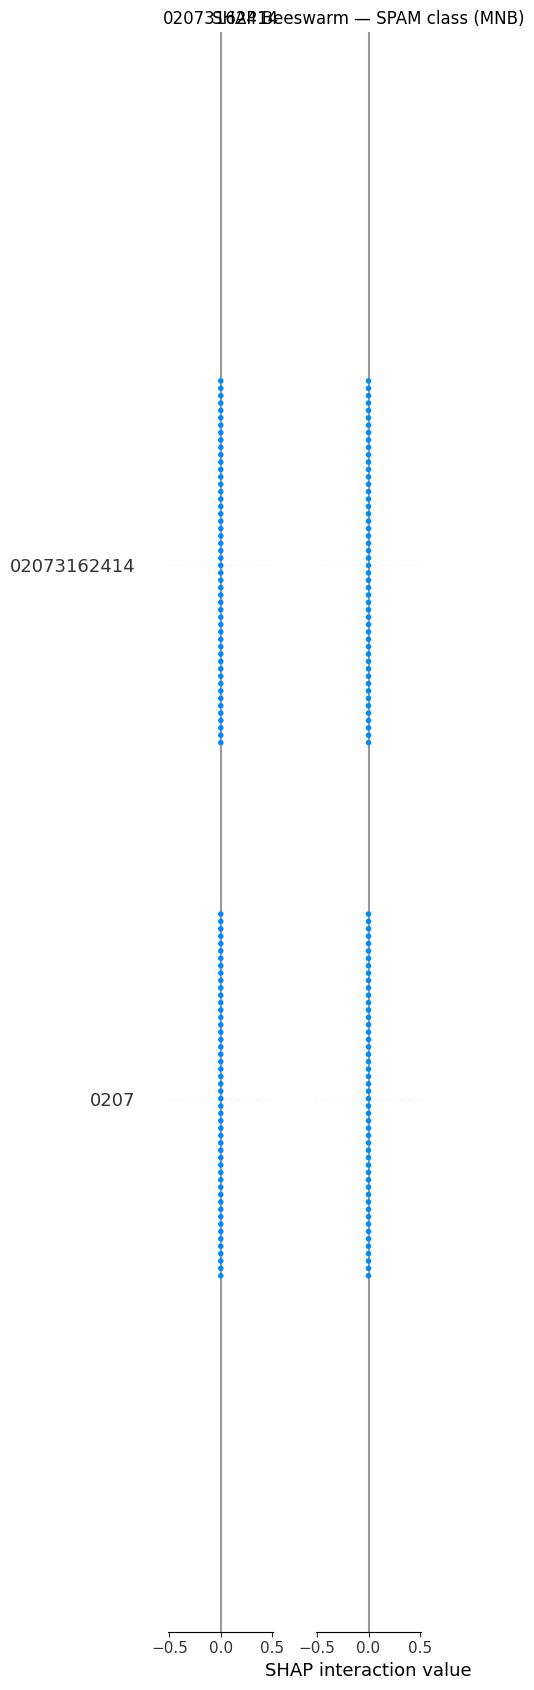

In [73]:

import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_mnb,
    X_test_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title("SHAP Beeswarm — SPAM class (MNB)")

plt.tight_layout()

plt.savefig('shap_mnb_beeswarm.png', dpi=150)

plt.show()

Plot A3: Force plot for one spam sample

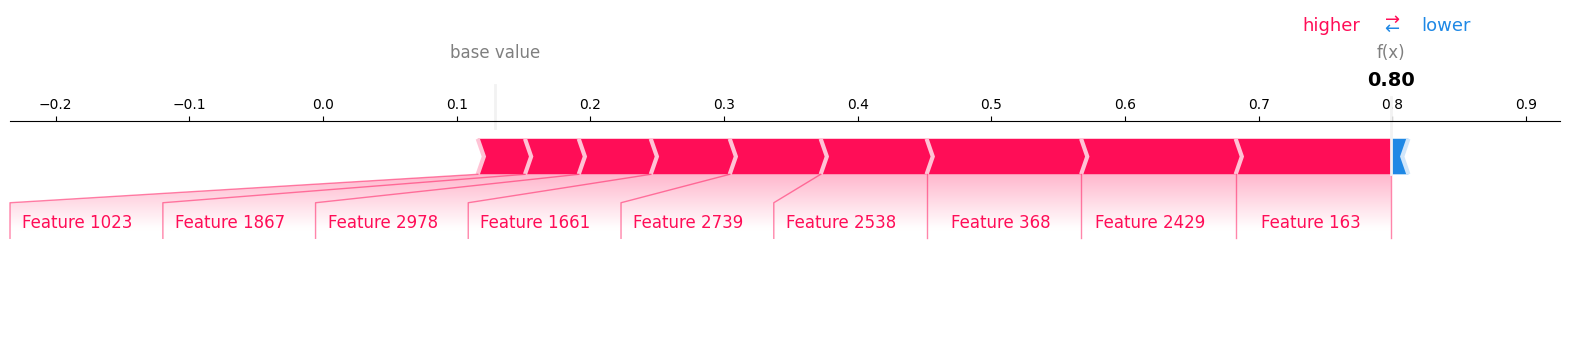

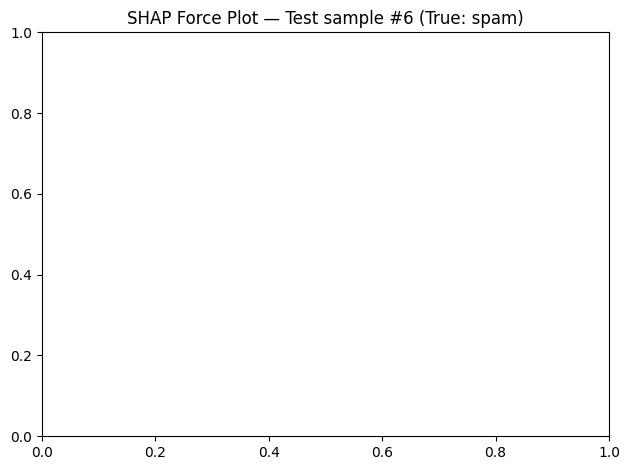

In [74]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

# Find first spam sample
spam_idx = next(i for i, lbl in enumerate(y_test[:50]) if lbl == 1)

# Correct SHAP force plot for multi-class output
shap.plots.force(
    explainer_mnb.expected_value[1],   # spam class base value
    shap_values_mnb[..., 1][spam_idx], # spam class shap values
    matplotlib=True
)

plt.title(f"SHAP Force Plot — Test sample #{spam_idx} (True: spam)")

plt.tight_layout()

plt.savefig("shap_mnb_force.png", dpi=150)

plt.show()

Plot A4: Dependence plot for the most important feature

<Figure size 1000x600 with 0 Axes>

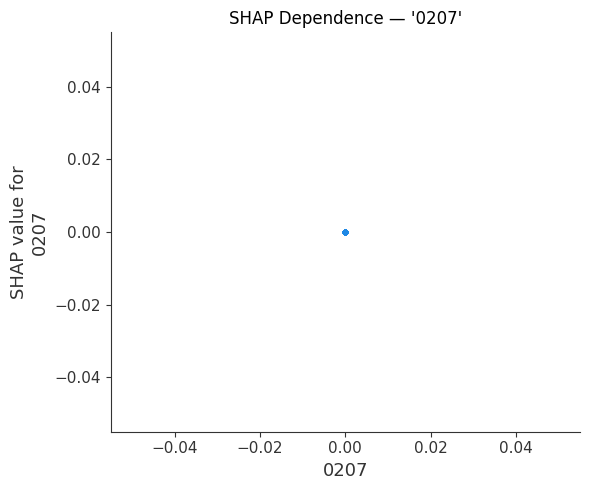


Most influential spam word (MNB): '0207'


In [75]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# =========================
# FIX SHAP DIMENSIONS
# =========================

# Use spam class SHAP values
spam_shap_values = shap_values_mnb[1]

# Match rows safely
num_rows = min(
    spam_shap_values.shape[0],
    X_test_sample.shape[0]
)

# Match columns safely
num_features = min(
    spam_shap_values.shape[1],
    X_test_sample.shape[1],
    len(feature_names)
)

# Trim everything
spam_shap_values = spam_shap_values[:num_rows, :num_features]

X_test_trimmed = X_test_sample[:num_rows, :num_features]

feature_names_trimmed = np.array(feature_names[:num_features])

# =========================
# TOP FEATURE
# =========================

top_feature_idx = np.abs(spam_shap_values).mean(axis=0).argmax()

top_feature = feature_names_trimmed[top_feature_idx]

# =========================
# DEPENDENCE PLOT
# =========================

plt.figure(figsize=(10, 6))

shap.dependence_plot(
    top_feature_idx,
    spam_shap_values,
    X_test_trimmed,
    feature_names=feature_names_trimmed,
    interaction_index=None,
    show=False
)

plt.title(f"SHAP Dependence — '{top_feature}'")

plt.tight_layout()

plt.savefig("shap_mnb_dependence.png", dpi=150)

plt.show()

print(f"\nMost influential spam word (MNB): '{top_feature}'")

PermutationExplainer explainer: 21it [00:48,  2.86s/it]



SHAP TABLE

   0207  02073162414  021  0578  07123456789  07xxxxxxxxx      0800  \
0   0.0          0.0  0.0   0.0          0.0          0.0 -0.000913   
1   0.0          0.0  0.0   0.0          0.0          0.0 -0.001146   
2   0.0          0.0  0.0   0.0          0.0          0.0 -0.000958   
3   0.0          0.0  0.0   0.0          0.0          0.0 -0.001235   
4   0.0          0.0  0.0   0.0          0.0          0.0 -0.000997   

   08000407165  08000776320  08000839402  ...        ym   yo  yoga  yogasana  \
0          0.0          0.0          0.0  ...  0.000004  0.0   0.0       0.0   
1          0.0          0.0          0.0  ...  0.000005  0.0   0.0       0.0   
2          0.0          0.0          0.0  ...  0.000002  0.0   0.0       0.0   
3          0.0          0.0          0.0  ...  0.000005  0.0   0.0       0.0   
4          0.0          0.0          0.0  ...  0.000004  0.0   0.0       0.0   

   yor        yr  yummi       yun       yup  zed  
0  0.0 -0.000026    0.0  0.0

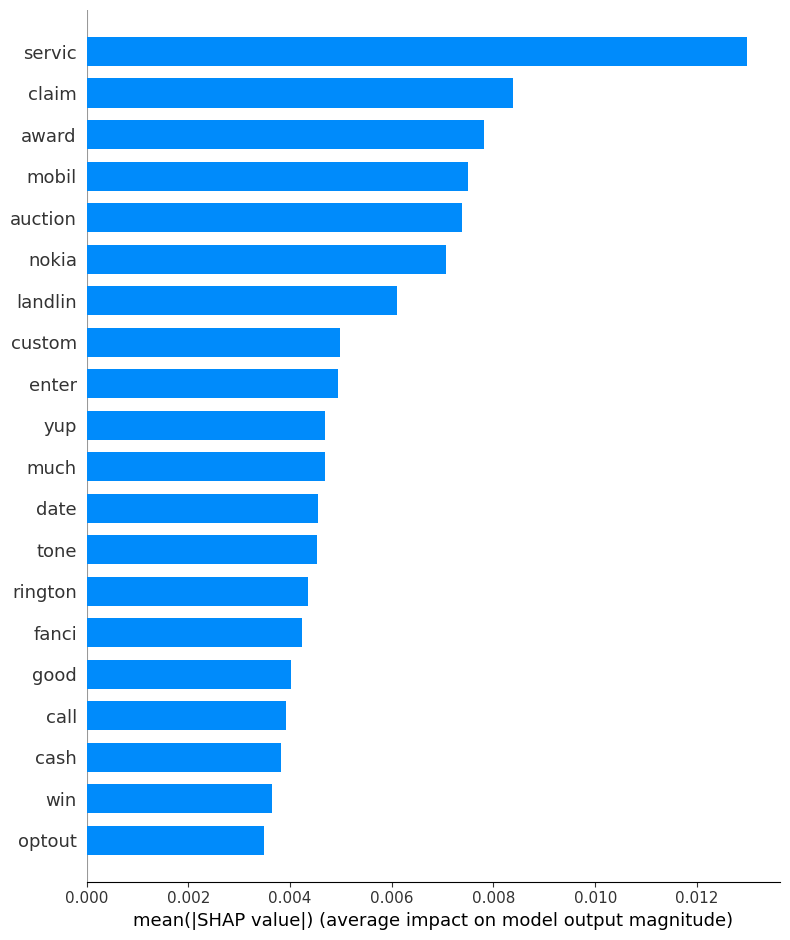

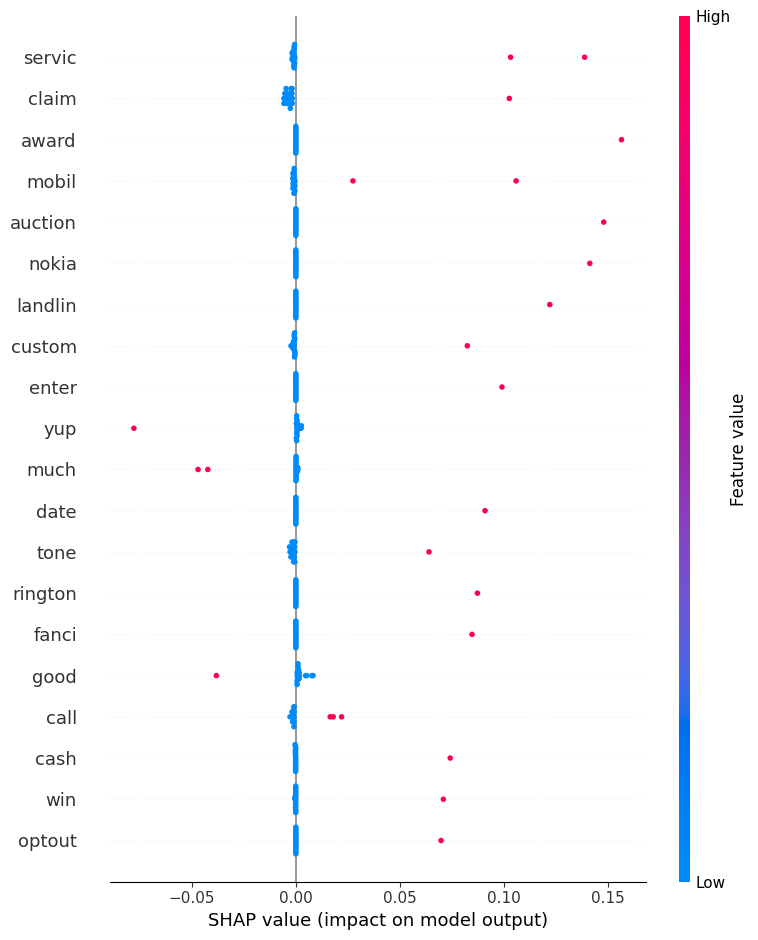

In [76]:
# =========================================================
# SHAP TABLE CREATION FULL FIXED CODE
# =========================================================

# IMPORT LIBRARIES
import shap
import pandas as pd
import numpy as np


# =========================================================
# CREATE SHAP EXPLAINER
# =========================================================

explainer = shap.Explainer(
    mnb.predict_proba,
    X_train
)


# =========================================================
# GENERATE SHAP VALUES
# =========================================================
# Using fewer samples for faster computation
# max_evals increased to avoid permutation error

shap_values = explainer(
    X_test[:20],
    max_evals=1000
)


# =========================================================
# FEATURE NAMES FROM TF-IDF
# =========================================================

feature_names = tfidf.get_feature_names_out()


# =========================================================
# CREATE SHAP TABLE / DATAFRAME
# =========================================================
# Binary classification:
# class 0 = ham
# class 1 = spam

shap_df = pd.DataFrame(
    shap_values.values[:, :, 1],
    columns=feature_names
)


# =========================================================
# DISPLAY FIRST 5 ROWS OF SHAP TABLE
# =========================================================

print("\n=======================================")

print("SHAP TABLE")

print("=======================================\n")

print(shap_df.head())


# =========================================================
# SHAPE OF SHAP TABLE
# =========================================================

print("\n=======================================")

print("SHAP TABLE SHAPE")

print("=======================================\n")

print(shap_df.shape)


# =========================================================
# NUMBER OF ATTRIBUTES / FEATURES
# =========================================================

print("\n=======================================")

print("NUMBER OF ATTRIBUTES")

print("=======================================\n")

print(
    "Number of Attributes in SHAP Table :",
    shap_df.shape[1]
)


# =========================================================
# NUMBER OF SAMPLES
# =========================================================

print(
    "Number of Samples :",
    shap_df.shape[0]
)


# =========================================================
# TOP IMPORTANT FEATURES
# =========================================================

importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Mean_SHAP_Value':
        np.abs(
            shap_values.values[:, :, 1]
        ).mean(axis=0)

})


# =========================================================
# SORT FEATURES
# =========================================================

importance_df = importance_df.sort_values(
    'Mean_SHAP_Value',
    ascending=False
)


# =========================================================
# DISPLAY TOP 10 IMPORTANT FEATURES
# =========================================================

print("\n=======================================")

print("TOP 10 IMPORTANT FEATURES")

print("=======================================\n")

print(importance_df.head(10))


# =========================================================
# OPTIONAL : SAVE SHAP TABLE TO CSV
# =========================================================

shap_df.to_csv(
    "shap_table.csv",
    index=False
)

print("\nSHAP table saved as shap_table.csv")


# =========================================================
# SHAP BAR PLOT
# =========================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test[:20],
    feature_names=feature_names,
    plot_type="bar"
)


# =========================================================
# SHAP BEESWARM PLOT
# =========================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test[:20],
    feature_names=feature_names
)

PART B: SHAP for BERT  (token-level explanations)



── SHAP: BERT (Partition Explainer) ──


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 6/10 [00:14<00:00, 14.44it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  90%|█████████ | 9/10 [00:31<00:03,  3.72s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [00:37,  5.30s/it]



Explaining: "SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 auction today! Auction is FREE 2 jo..."


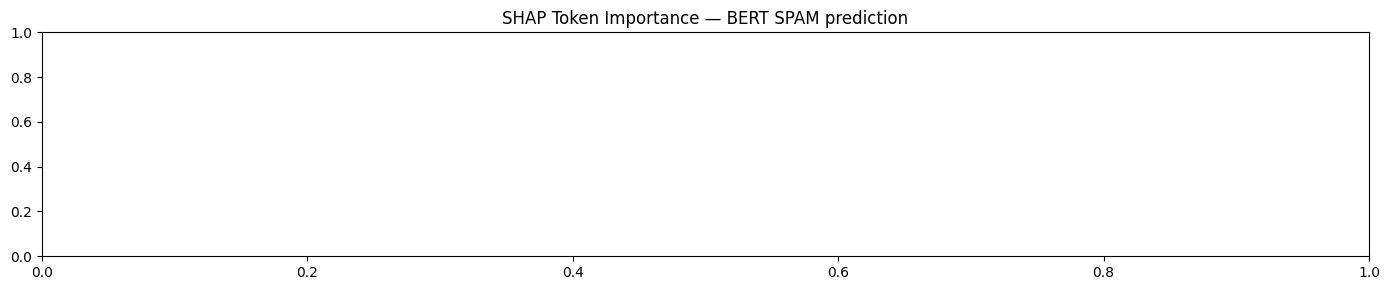

In [77]:
print("\n── SHAP: BERT (Partition Explainer) ──")

from transformers import pipeline as hf_pipeline

# Wrap fine-tuned BERT as a HuggingFace text-classification pipeline
bert_pipeline = hf_pipeline(
    task='text-classification',
    model=bert_model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True          # returns [{'label':..,'score':..}, ...]
)

# Partition explainer — masks tokens and measures prediction delta
explainer_bert   = shap.Explainer(bert_pipeline)

# Use 10 samples (BERT SHAP is compute-heavy; increase on GPU)
sample_texts     = list(X_test_b[:10])
shap_values_bert = explainer_bert(sample_texts)
# shape: [n_samples, n_tokens, n_classes]

# Find a spam example in the sample
spam_text_idx = next(
    (i for i, lbl in enumerate(y_test_b[:10]) if lbl == 1), 0
)
print(f"\nExplaining: \"{sample_texts[spam_text_idx][:80]}...\"")

# ── Plot B1: Token-level text plot for one spam prediction ─────
plt.figure(figsize=(14, 3))
shap.plots.text(shap_values_bert[spam_text_idx, :, 1], display=False)
plt.title("SHAP Token Importance — BERT SPAM prediction")
plt.tight_layout()
plt.savefig('shap_bert_text.png', dpi=150)
plt.show()

Plot B2: Bar — mean token importance across all samples

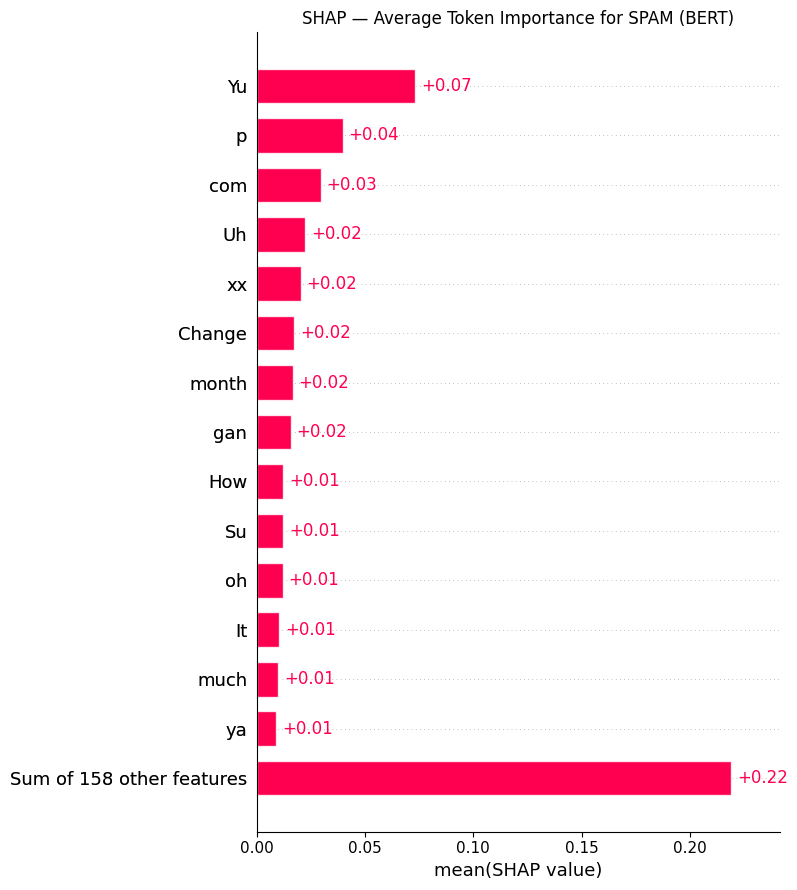

In [78]:
plt.figure()
shap.plots.bar(
    shap_values_bert[:, :, 1].mean(0),   # mean over samples, spam class
    max_display=15,
    show=False
)
plt.title("SHAP — Average Token Importance for SPAM (BERT)")
plt.tight_layout()
plt.savefig('shap_bert_bar.png', dpi=150)
plt.show()

Plot B3: Waterfall for one prediction

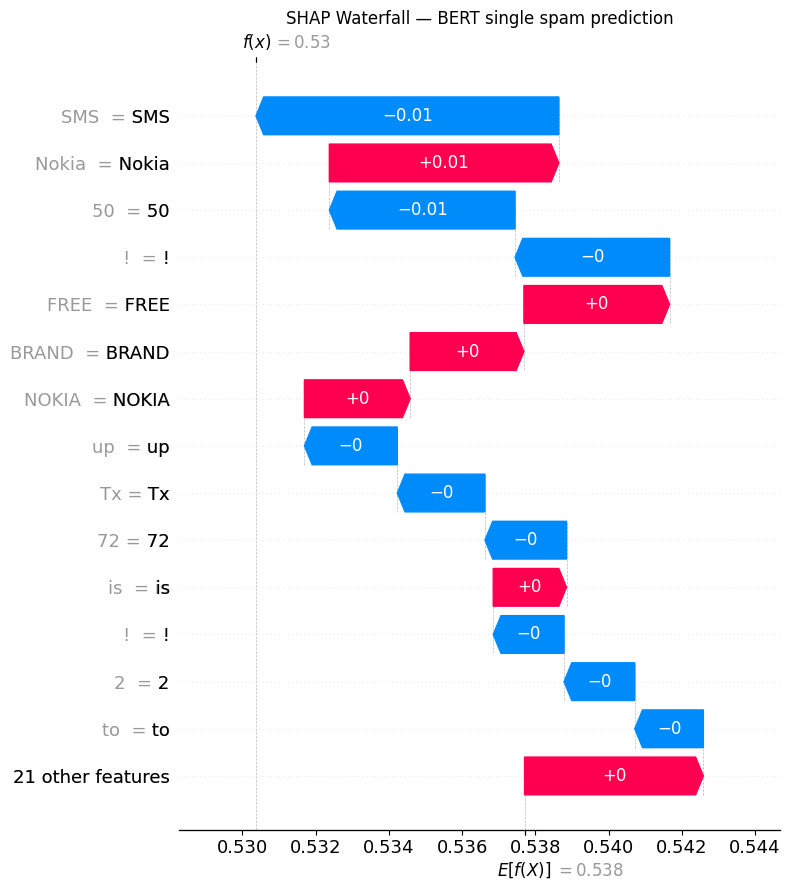

In [79]:
plt.figure()
shap.plots.waterfall(
    shap_values_bert[spam_text_idx, :, 1],
    max_display=15,
    show=False
)
plt.title("SHAP Waterfall — BERT single spam prediction")
plt.tight_layout()
plt.savefig('shap_bert_waterfall.png', dpi=150)
plt.show()

Plot B4: Heatmap across all sample tokens

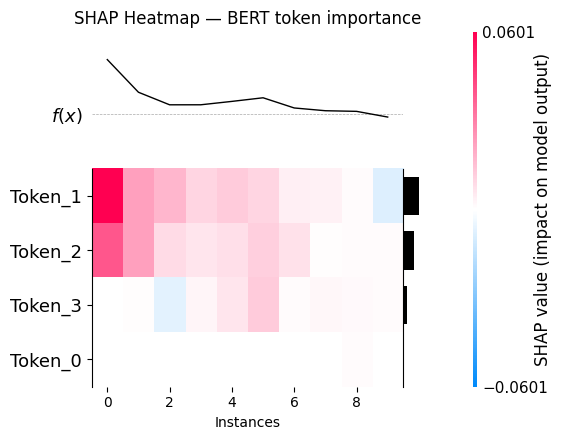

In [80]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# =========================
# FIX SHAP BERT HEATMAP
# =========================

num_samples = 10

# Get minimum token length
min_len = min(
    sv.values.shape[0]
    for sv in shap_values_bert[:num_samples]
)

# Create 2D SHAP matrix
heatmap_values = np.array([
    sv.values[:min_len, 1]
    for sv in shap_values_bert[:num_samples]
])

# Create dummy feature names
feature_names = [f"Token_{i}" for i in range(min_len)]

# Create Explanation object properly
heatmap_exp = shap.Explanation(
    values=heatmap_values,
    feature_names=feature_names
)

# Plot
plt.figure(figsize=(12, 6))

shap.plots.heatmap(
    heatmap_exp,
    max_display=15,
    show=False
)

plt.title("SHAP Heatmap — BERT token importance")

plt.tight_layout()

plt.savefig("shap_bert_heatmap.png", dpi=150)

plt.show()

6. MODEL IMPROVEMENT — TF-IDF max_features tuning


── Tuning TF-IDF max_features ──
 max_features  Accuracy  Precision
          500  0.979651   0.973214
         1000  0.981589   1.000000
         2000  0.976744   1.000000
         3000  0.971899   1.000000
         5000  0.965116   1.000000


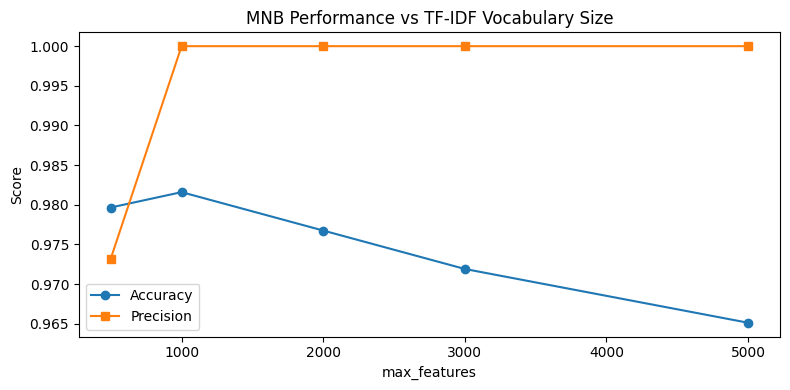

In [81]:
print("\n── Tuning TF-IDF max_features ──")

results = []
for max_ft in [500, 1000, 2000, 3000, 5000]:
    tfidf_temp = TfidfVectorizer(max_features=max_ft)
    X_temp     = tfidf_temp.fit_transform(df['transformed_text']).toarray()
    Xtr, Xte, ytr, yte = train_test_split(X_temp, y, test_size=0.2, random_state=2)

    mnb_temp = MultinomialNB()
    mnb_temp.fit(Xtr, ytr)
    ypred = mnb_temp.predict(Xte)
    results.append({
        'max_features': max_ft,
        'Accuracy':     accuracy_score(yte, ypred),
        'Precision':    precision_score(yte, ypred)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(results_df['max_features'], results_df['Accuracy'],  marker='o', label='Accuracy')
plt.plot(results_df['max_features'], results_df['Precision'], marker='s', label='Precision')
plt.xlabel('max_features')
plt.ylabel('Score')
plt.title('MNB Performance vs TF-IDF Vocabulary Size')
plt.legend()
plt.tight_layout()
plt.show()

FINAL SUMMARY

In [82]:
print("\n" + "="*60)
print("  FINAL MODEL COMPARISON")
print("="*60)
print(performance_df.sort_values('Precision', ascending=False).to_string(index=False))
print("\nSaved plots:")
print("  shap_mnb_bar.png        — MNB global feature importance")
print("  shap_mnb_beeswarm.png   — MNB beeswarm (magnitude + direction)")
print("  shap_mnb_force.png      — MNB single prediction force plot")
print("  shap_mnb_dependence.png — MNB top feature dependence plot")
print("  shap_bert_text.png      — BERT token-level text highlight")
print("  shap_bert_bar.png       — BERT average token importance bar")
print("  shap_bert_waterfall.png — BERT single prediction waterfall")
print("  shap_bert_heatmap.png   — BERT token heatmap across samples")


  FINAL MODEL COMPARISON
Algorithm  Accuracy  Precision   Recall  F1 Score  Weighted F1
       KN  0.912791   1.000000 0.291339  0.451220     0.890927
       NB  0.971899   1.000000 0.771654  0.871111     0.970310
      SVC  0.977713   0.990566 0.826772  0.901288     0.976837
      ETC  0.971899   0.990000 0.779528  0.872247     0.970435
       RF  0.970930   0.989899 0.771654  0.867257     0.969351
      xgb  0.973837   0.980769 0.803150  0.883117     0.972699
     GBDT  0.952519   0.975610 0.629921  0.765550     0.947984
       LR  0.958333   0.937500 0.708661  0.807175     0.955788
      BgC  0.964147   0.894737 0.803150  0.846473     0.963308
 AdaBoost  0.928295   0.844156 0.511811  0.637255     0.920471
       DT  0.936047   0.814433 0.622047  0.705357     0.932285
     BERT  0.123062   0.123062 1.000000  0.219154     0.026970
     BERT  0.123062   0.123062      NaN       NaN          NaN

Saved plots:
  shap_mnb_bar.png        — MNB global feature importance
  shap_mnb_beeswarm.

In [83]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))